In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "A07607236202602121443442025_transporte_acp.csv",
    encoding="latin-1"
)

In [3]:
df.head()


,Año,Mes,Transito de Naves Alto Calado Panamax,Transito de Naves Pequeño Calado Panamax,Ingresos por Peaje Panamax,Toneladas Netas Panamax,Volumen de Carga Panamax,Transito de Naves NeoPanamax,Ingresos por Peaje NeoPanamax,Tonelada Netas Neopanamax,Volumen de Carga NeoPanamax
0,2020,Enero,826,149,110198056,21167387,13324583,308,135551279,23811798,9311252
1,2020,Febrero,753,206,100158695,19293825,13054336,268,112186169,19811487,8662008
2,2020,Marzo,825,124,110757041,21512145,15397768,261,105134233,19232310,7836721
3,2020,Abril,698,53,96144271,17615626,13232901,271,121704852,19898460,9636220
4,2020,Mayo,640,43,85960793,15530225,12631808,254,115570390,18800359,7521629


In [4]:
df.columns

Index(['Año', 'Mes', 'Transito de Naves Alto Calado Panamax',
       'Transito de Naves Pequeño Calado Panamax',
       'Ingresos por Peaje Panamax', 'Toneladas Netas Panamax',
       'Volumen de Carga Panamax', 'Transito de Naves NeoPanamax',
       'Ingresos por Peaje NeoPanamax', 'Tonelada Netas Neopanamax',
       'Volumen de Carga NeoPanamax'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 11 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   Año                                       72 non-null     int64
 1   Mes                                       72 non-null     str  
 2   Transito de Naves Alto Calado Panamax     72 non-null     int64
 3   Transito de Naves Pequeño Calado Panamax  72 non-null     int64
 4   Ingresos por Peaje Panamax                72 non-null     int64
 5   Toneladas Netas Panamax                   72 non-null     int64
 6   Volumen de Carga Panamax                  72 non-null     int64
 7   Transito de Naves NeoPanamax              72 non-null     int64
 8   Ingresos por Peaje NeoPanamax             72 non-null     int64
 9   Tonelada Netas Neopanamax                 72 non-null     int64
 10  Volumen de Carga NeoPanamax               72 non-null     int64
dtypes: int

In [6]:
df.isnull().sum()

Año                                         0
Mes                                         0
Transito de Naves Alto Calado Panamax       0
Transito de Naves Pequeño Calado Panamax    0
Ingresos por Peaje Panamax                  0
Toneladas Netas Panamax                     0
Volumen de Carga Panamax                    0
Transito de Naves NeoPanamax                0
Ingresos por Peaje NeoPanamax               0
Tonelada Netas Neopanamax                   0
Volumen de Carga NeoPanamax                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.rename(columns={

    "Ingresos por Peaje Panamax":
    "Ingresos Panamax",

    "Ingresos por Peaje NeoPanamax":
    "Ingresos NeoPanamax",

    "Tonelada Netas Neopanamax":
    "Toneladas Netas NeoPanamax"

})

In [9]:
df["Año"].unique()

array([2020, 2021, 2022, 2023, 2024, 2025])

In [11]:
df["Ingresos Totales"] = (

    df["Ingresos Panamax"]

    +

    df["Ingresos NeoPanamax"]

)

In [12]:
df["Total Transitos"] = (

    df["Transito de Naves Alto Calado Panamax"]

    +

    df["Transito de Naves Pequeño Calado Panamax"]

    +

    df["Transito de Naves NeoPanamax"]

)

In [13]:
df["Volumen Total"] = (

    df["Volumen de Carga Panamax"]

    +

    df["Volumen de Carga NeoPanamax"]

)

In [14]:
df["Toneladas Totales"] = (

    df["Toneladas Netas Panamax"]

    +

    df["Toneladas Netas NeoPanamax"]

)

Año
2020    2710663062
2021    2982729941
2022    3015788432
2023    3323201423
2024    3376290655
2025    4118449143
Name: Ingresos Totales, dtype: int64


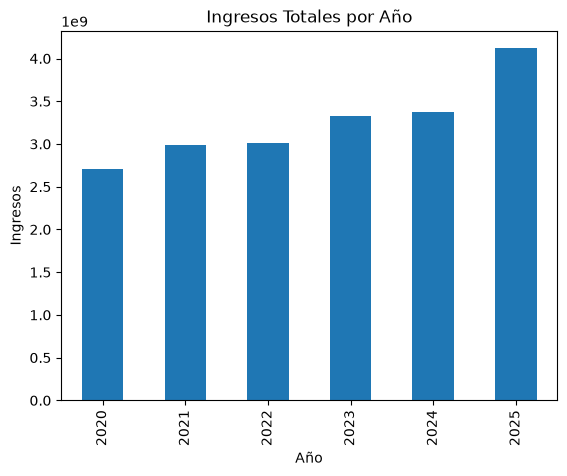

In [15]:
ingresos = (

    df.groupby("Año")["Ingresos Totales"]

    .sum()

)

print(ingresos)

ingresos.plot(kind="bar")

plt.title("Ingresos Totales por Año")
plt.xlabel("Año")
plt.ylabel("Ingresos")

plt.show()

Año
2020    12983
2021    13523
2022    14274
2023    13216
2024    11802
2025    13451
Name: Total Transitos, dtype: int64


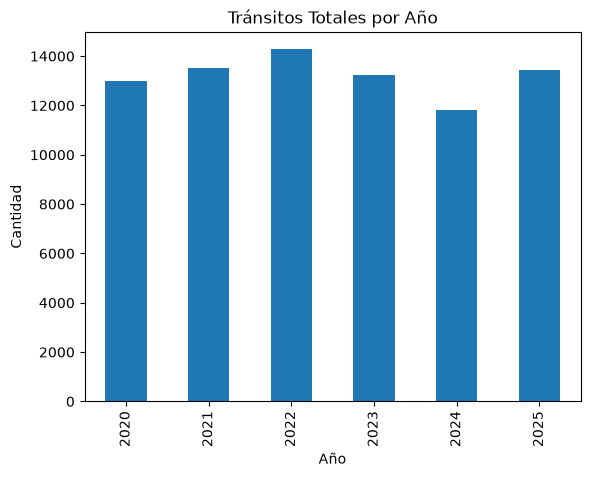

In [16]:
transitos = (

    df.groupby("Año")["Total Transitos"]

    .sum()

)

print(transitos)

transitos.plot(kind="bar")

plt.title("Tránsitos Totales por Año")
plt.xlabel("Año")
plt.ylabel("Cantidad")

plt.show()

Año
2020    263594118
2021    292319028
2022    293493382
2023    262713655
2024    219389618
2025    250536383
Name: Volumen Total, dtype: int64


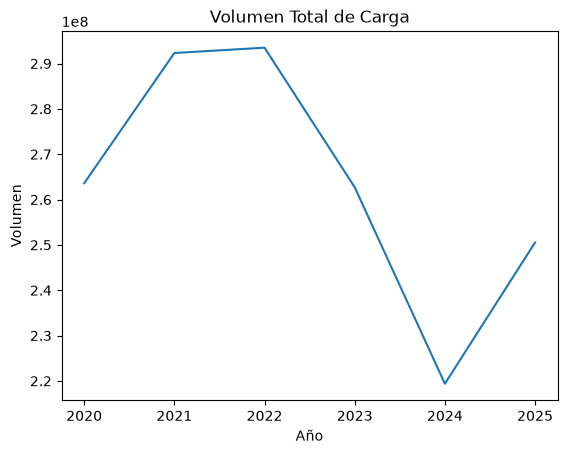

In [17]:
volumen = (

    df.groupby("Año")["Volumen Total"]

    .sum()

)

print(volumen)

volumen.plot(kind="line")

plt.title("Volumen Total de Carga")
plt.xlabel("Año")
plt.ylabel("Volumen")

plt.show()

Año
2020    475712936
2021    518517898
2022    517052296
2023    485438725
2024    437101537
2025    493201981
Name: Toneladas Totales, dtype: int64


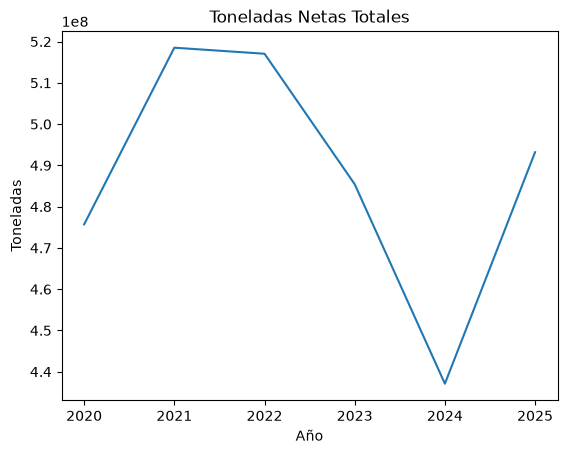

In [18]:
toneladas = (

    df.groupby("Año")["Toneladas Totales"]

    .sum()

)

print(toneladas)

toneladas.plot(kind="line")

plt.title("Toneladas Netas Totales")
plt.xlabel("Año")
plt.ylabel("Toneladas")

plt.show()

Panamax        8562568907
NeoPanamax    10964553749
dtype: int64


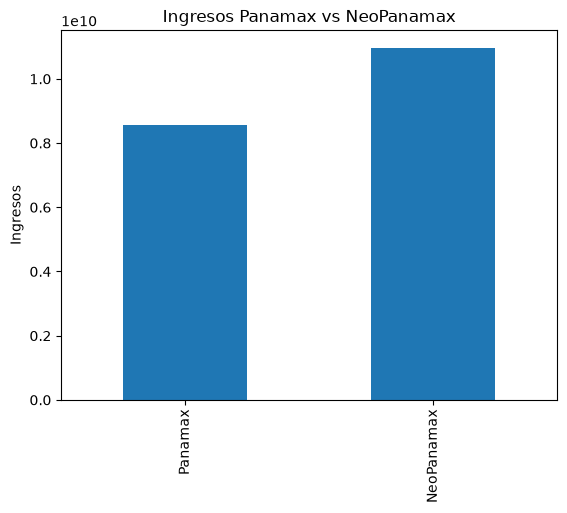

In [19]:

ingresos = pd.Series({

    "Panamax":

    df["Ingresos Panamax"].sum(),

    "NeoPanamax":

    df["Ingresos NeoPanamax"].sum()

})

print(ingresos)

ingresos.plot(kind="bar")

plt.title("Ingresos Panamax vs NeoPanamax")
plt.ylabel("Ingresos")

plt.show()

Panamax       58781
NeoPanamax    20468
dtype: int64


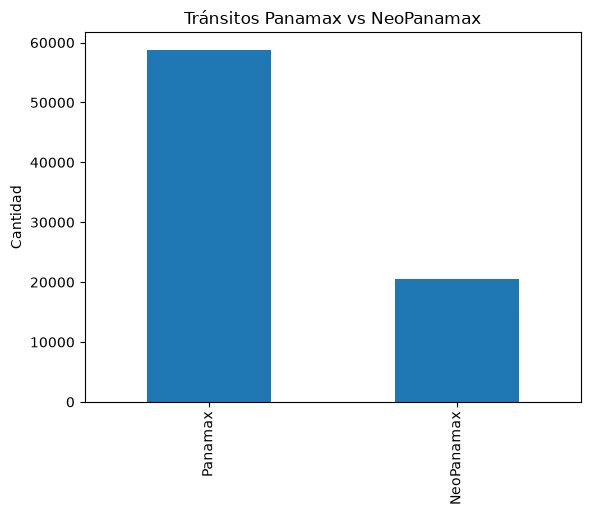

In [20]:
transitos = pd.Series({

    "Panamax":

    df["Transito de Naves Alto Calado Panamax"].sum()

    +

    df["Transito de Naves Pequeño Calado Panamax"].sum(),

    "NeoPanamax":

    df["Transito de Naves NeoPanamax"].sum()

})

print(transitos)

transitos.plot(kind="bar")

plt.title("Tránsitos Panamax vs NeoPanamax")
plt.ylabel("Cantidad")

plt.show()

Mes
Abril         1603412398
Agosto        1713218046
Diciembre     1710662947
Enero         1639761674
Febrero       1487999600
Julio         1663404177
Junio         1545068295
Marzo         1601149263
Mayo          1595213722
Noviembre     1638167948
Octubre       1715364645
Septiembre    1613699941
Name: Ingresos Totales, dtype: int64


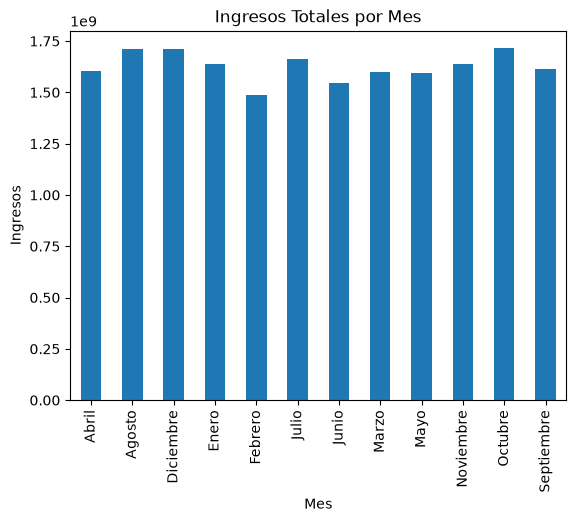

In [21]:
ingresos_mes = (

    df.groupby("Mes")["Ingresos Totales"]

    .sum()

)

print(ingresos_mes)

ingresos_mes.plot(kind="bar")

plt.title("Ingresos Totales por Mes")
plt.ylabel("Ingresos")

plt.show()

Panamax       58781
NeoPanamax    20468
dtype: int64


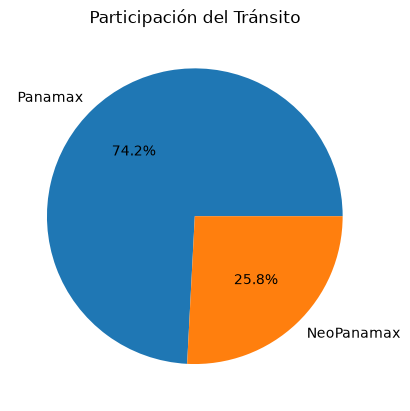

In [22]:
participacion = pd.Series({

    "Panamax":

    df["Transito de Naves Alto Calado Panamax"].sum()

    +

    df["Transito de Naves Pequeño Calado Panamax"].sum(),

    "NeoPanamax":

    df["Transito de Naves NeoPanamax"].sum()

})

print(participacion)

participacion.plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.ylabel("")
plt.title("Participación del Tránsito")

plt.show()

Panamax       954463099
NeoPanamax    627583085
dtype: int64


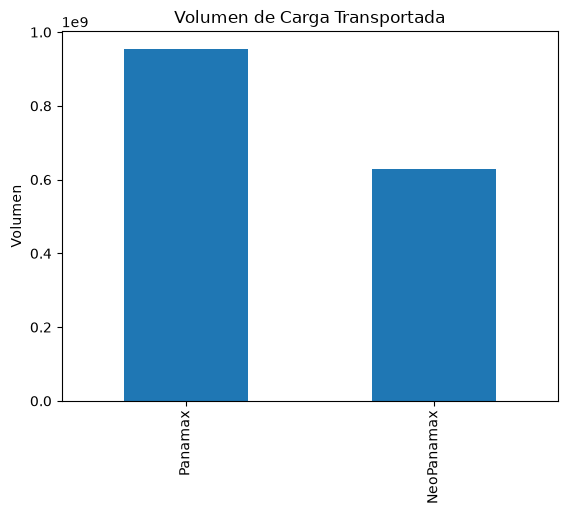

In [23]:
volumen = pd.Series({

    "Panamax":

    df["Volumen de Carga Panamax"].sum(),

    "NeoPanamax":

    df["Volumen de Carga NeoPanamax"].sum()

})

print(volumen)

volumen.plot(kind="bar")

plt.title("Volumen de Carga Transportada")
plt.ylabel("Volumen")

plt.show()

Año
2020    2.258886e+08
2021    2.485608e+08
2022    2.513157e+08
2023    2.769335e+08
2024    2.813576e+08
2025    3.432041e+08
Name: Ingresos Totales, dtype: float64


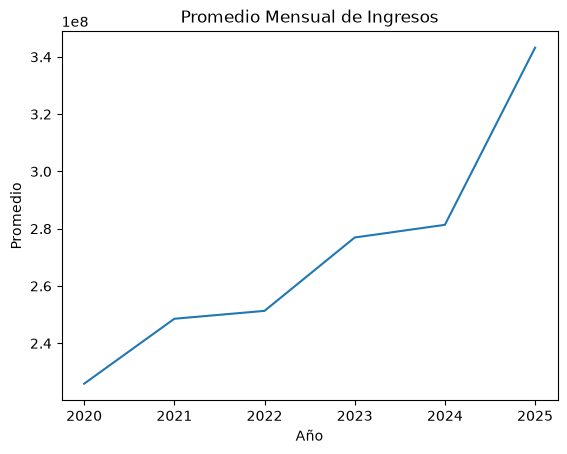

In [24]:
promedio = (

    df.groupby("Año")["Ingresos Totales"]

    .mean()

)

print(promedio)

promedio.plot(kind="line")

plt.title("Promedio Mensual de Ingresos")
plt.xlabel("Año")
plt.ylabel("Promedio")

plt.show()

Año
2020    1081.916667
2021    1126.916667
2022    1189.500000
2023    1101.333333
2024     983.500000
2025    1120.916667
Name: Total Transitos, dtype: float64


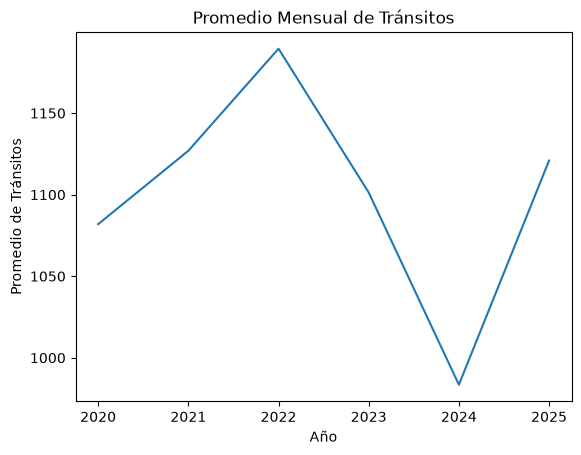

In [25]:
# Promedio de Tránsitos Mensuales por Año

promedio_transitos = (

    df.groupby("Año")["Total Transitos"]

    .mean()

)

print(promedio_transitos)

promedio_transitos.plot(kind="line")

plt.title("Promedio Mensual de Tránsitos")
plt.xlabel("Año")
plt.ylabel("Promedio de Tránsitos")

plt.show()

Panamax        8562568907
NeoPanamax    10964553749
dtype: int64


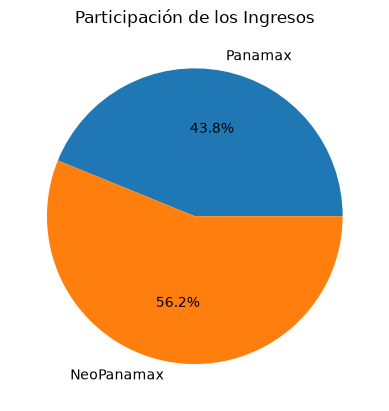

In [26]:
# Participación de los Ingresos

participacion = pd.Series({

    "Panamax":

    df["Ingresos Panamax"].sum(),

    "NeoPanamax":

    df["Ingresos NeoPanamax"].sum()

})


print(participacion)

participacion.plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.ylabel("")
plt.title("Participación de los Ingresos")

plt.show()